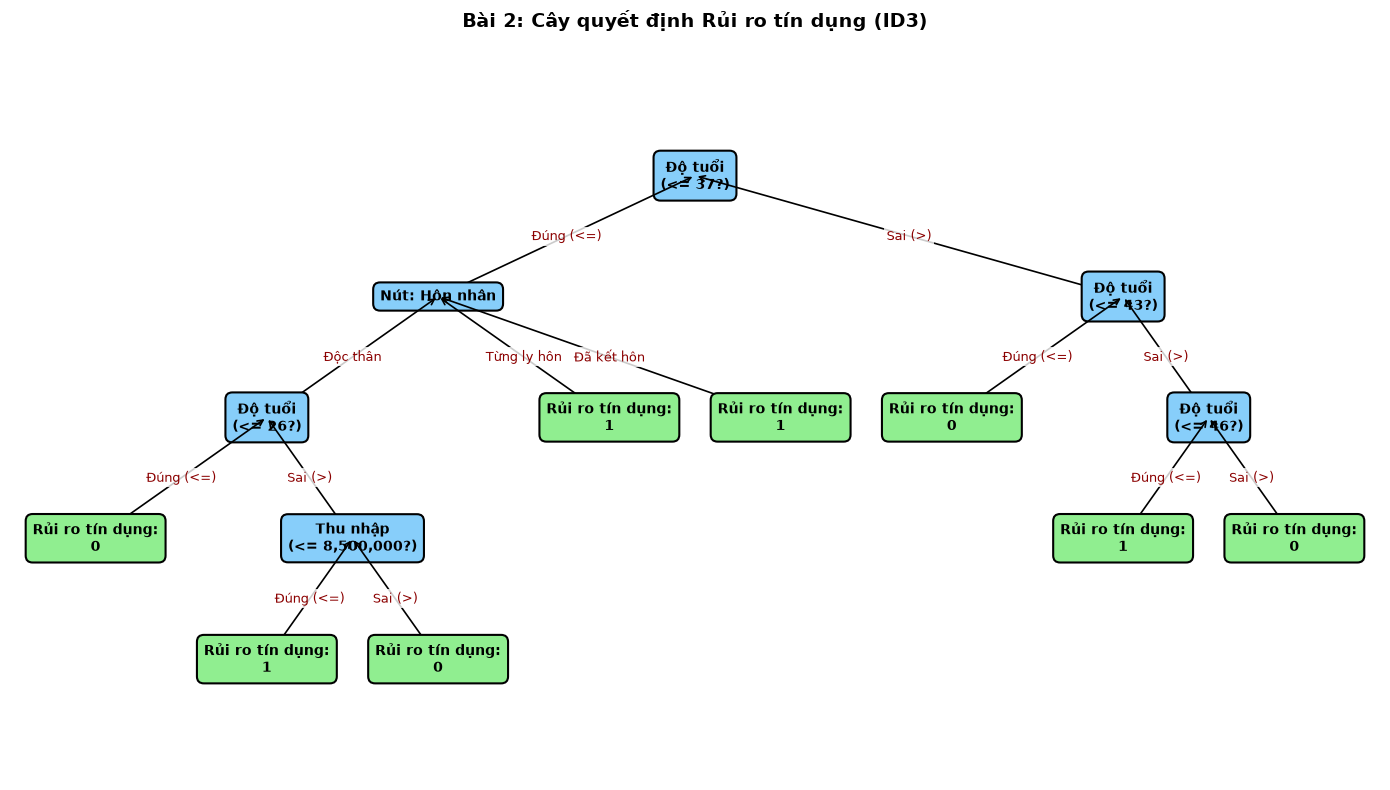

In [3]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. TÍNH ENTROPY & INFORMATION GAIN (CÓ BIẾN SỐ LIÊN TỤC)
# ----------------------------------------------------
def calculate_entropy(df, target_col):
    total_count = len(df)
    if total_count == 0:
        return 0
    value_counts = df[target_col].value_counts()
    entropy = 0.0
    for count in value_counts:
        p = count / total_count
        entropy -= p * math.log2(p)
    return entropy

def gain_categorical(df, feature_col, target_col):
    base_entropy = calculate_entropy(df, target_col)
    total_count = len(df)
    weighted_entropy = 0.0
    for val, group in df.groupby(feature_col):
        prob = len(group) / total_count
        weighted_entropy += prob * calculate_entropy(group, target_col)
    return base_entropy - weighted_entropy

def best_split_continuous(df, feature_col, target_col):
    """Tìm ngưỡng cắt (threshold) tối ưu cho thuộc tính số"""
    base_entropy = calculate_entropy(df, target_col)
    sorted_df = df.sort_values(by=feature_col)
    values = sorted_df[feature_col].unique()
    
    if len(values) <= 1:
        return 0, None
    
    best_gain = -1
    best_threshold = None
    total_count = len(df)
    
    for i in range(len(values) - 1):
        threshold = (values[i] + values[i+1]) / 2.0
        left_sub = df[df[feature_col] <= threshold]
        right_sub = df[df[feature_col] > threshold]
        
        prob_left = len(left_sub) / total_count
        prob_right = len(right_sub) / total_count
        
        weighted_entropy = prob_left * calculate_entropy(left_sub, target_col) + \
                           prob_right * calculate_entropy(right_sub, target_col)
        
        gain = base_entropy - weighted_entropy
        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold
            
    return best_gain, best_threshold

# ----------------------------------------------------
# 2. XÂY DỰNG CÂY QUYẾT ĐỊNH ID3
# ----------------------------------------------------
class Node:
    def __init__(self, feature=None, threshold=None, is_leaf=False, value=None):
        self.feature = feature
        self.threshold = threshold
        self.branches = {}
        self.left = None
        self.right = None
        self.is_leaf = is_leaf
        self.value = value

def build_tree(df, features, target_col):
    unique_targets = df[target_col].unique()
    if len(unique_targets) == 1:
        return Node(is_leaf=True, value=unique_targets[0])
    
    if len(features) == 0:
        most_common = df[target_col].mode()[0]
        return Node(is_leaf=True, value=most_common)
    
    best_feature = None
    best_gain = -1
    best_threshold = None
    
    for col in features:
        if pd.api.types.is_numeric_dtype(df[col]):
            gain, threshold = best_split_continuous(df, col, target_col)
        else:
            gain = gain_categorical(df, col, target_col)
            threshold = None
            
        if gain > best_gain:
            best_gain = gain
            best_feature = col
            best_threshold = threshold
            
    if best_gain <= 0 or best_feature is None:
        most_common = df[target_col].mode()[0]
        return Node(is_leaf=True, value=most_common)
    
    node = Node(feature=best_feature, threshold=best_threshold)
    
    if best_threshold is not None:
        left_df = df[df[best_feature] <= best_threshold]
        right_df = df[df[best_feature] > best_threshold]
        node.left = build_tree(left_df, features, target_col)
        node.right = build_tree(right_df, features, target_col)
    else:
        remaining_features = [f for f in features if f != best_feature]
        for val in df[best_feature].unique():
            sub_df = df[df[best_feature] == val]
            node.branches[val] = build_tree(sub_df, remaining_features, target_col)
            
    return node

# ----------------------------------------------------
# 3. HÀM VẼ CÂY BẰNG MATPLOTLIB
# ----------------------------------------------------
def get_tree_leaf_count(node):
    if node.is_leaf:
        return 1
    if node.threshold is not None:
        return get_tree_leaf_count(node.left) + get_tree_leaf_count(node.right)
    return sum(get_tree_leaf_count(child) for child in node.branches.values())

def get_tree_depth(node):
    if node.is_leaf:
        return 1
    if node.threshold is not None:
        return 1 + max(get_tree_depth(node.left), get_tree_depth(node.right))
    return 1 + max(get_tree_depth(child) for child in node.branches.values())

def plot_node(ax, text, center_pt, parent_pt, edge_text, is_leaf=False):
    bbox_props = dict(boxstyle="round,pad=0.5", 
                      fc="#90ee90" if is_leaf else "#87cefa", 
                      ec="black", lw=1.5)
    if parent_pt:
        ax.annotate('', xy=center_pt, xycoords='axes fraction',
                    xytext=parent_pt, textcoords='axes fraction',
                    arrowprops=dict(arrowstyle="<-", color="black", lw=1.2))
        mid_x = (center_pt[0] + parent_pt[0]) / 2.0
        mid_y = (center_pt[1] + parent_pt[1]) / 2.0
        ax.text(mid_x, mid_y, edge_text, fontsize=9, color='darkred',
                ha='center', va='center', bbox=dict(boxstyle="square,pad=0.2", fc="white", ec="none", alpha=0.8))

    ax.text(center_pt[0], center_pt[1], text, fontsize=10, fontweight='bold',
            ha='center', va='center', bbox=bbox_props)

def plot_tree_recursive(ax, node, parent_pt, edge_text, x_left, x_right, y, depth_step):
    x_center = (x_left + x_right) / 2.0
    current_pt = (x_center, y)

    if node.is_leaf:
        plot_node(ax, f"Rủi ro tín dụng:\n{node.value}", current_pt, parent_pt, edge_text, is_leaf=True)
        return

    if node.threshold is not None:
        text = f"{node.feature}\n(<= {node.threshold:,.0f}?)"
        plot_node(ax, text, current_pt, parent_pt, edge_text)

        left_leaves = get_tree_leaf_count(node.left)
        right_leaves = get_tree_leaf_count(node.right)
        total_leaves = left_leaves + right_leaves
        split_x = x_left + (x_right - x_left) * (left_leaves / total_leaves)

        plot_tree_recursive(ax, node.left, current_pt, "Đúng (<=)", x_left, split_x, y - depth_step, depth_step)
        plot_tree_recursive(ax, node.right, current_pt, "Sai (>)", split_x, x_right, y - depth_step, depth_step)
    else:
        text = f"Nút: {node.feature}"
        plot_node(ax, text, current_pt, parent_pt, edge_text)

        total_leaves = get_tree_leaf_count(node)
        current_x = x_left
        for val, child in node.branches.items():
            child_leaves = get_tree_leaf_count(child)
            next_x = current_x + (x_right - x_left) * (child_leaves / total_leaves)
            plot_tree_recursive(ax, child, current_pt, str(val), current_x, next_x, y - depth_step, depth_step)
            current_x = next_x

def draw_decision_tree(root, title="Cây quyết định ID3"):
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')
    depth = get_tree_depth(root)
    depth_step = 1.0 / (depth + 1)
    plot_tree_recursive(ax, root, None, "", 0.0, 1.0, 1.0 - depth_step, depth_step)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------
# 4. CHẠY BÀI 2
# ----------------------------------------------------
data_2 = {
    'Độ tuổi': [25, 40, 35, 27, 31, 36, 48, 26, 33, 29, 38, 44, 42, 28, 30],
    'Hôn nhân': ['Độc thân', 'Đã kết hôn', 'Từng ly hôn', 'Đã kết hôn', 'Độc thân', 
                 'Đã kết hôn', 'Độc thân', 'Đã kết hôn', 'Từng ly hôn', 'Độc thân', 
                 'Đã kết hôn', 'Độc thân', 'Đã kết hôn', 'Độc thân', 'Đã kết hôn'],
    'Sở hữu BĐS': ['Ở cùng bố mẹ', 'Nhà sở hữu', 'Nhà thuê', 'Ở cùng bố mẹ', 'Nhà thuê', 
                   'Nhà sở hữu', 'Nhà thuê', 'Nhà thuê', 'Ở cùng bố mẹ', 'Nhà thuê', 
                   'Nhà sở hữu', 'Nhà sở hữu', 'Nhà sở hữu', 'Nhà thuê', 'Ở cùng bố mẹ'],
    'Thu nhập': [7000000, 18000000, 12000000, 9000000, 6000000, 
                 8000000, 7000000, 8000000, 5000000, 10000000, 
                 15000000, 14000000, 10000000, 7000000, 6000000],
    'Rủi ro tín dụng': [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1]
}

df2 = pd.DataFrame(data_2)
features_2 = ['Độ tuổi', 'Hôn nhân', 'Sở hữu BĐS', 'Thu nhập']
tree_2 = build_tree(df2, features_2, 'Rủi ro tín dụng')

draw_decision_tree(tree_2, title="Bài 2: Cây quyết định Rủi ro tín dụng (ID3)")